# Notebook 04 — Temporal baselines

Establish leakage-safe temporal baseline performance **before** ML modeling.

This notebook reuses the frozen Notebook 03 contract (splits + label indexes + high-pollution flags). It does **not** rebuild labels or alter the contract.


## 0. Imports and setup


In [1]:
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
# Dependency preflight: parquet support (read/write)
try:
    import pyarrow  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "Missing optional dependency 'pyarrow' required for parquet IO in this notebook. "
        "Install with: pip install pyarrow"
    ) from exc


In [3]:
def find_project_root(start_path: Path) -> Path:
    """Find the project root by walking upward from a start path.

    Markers searched (in priority order):
    - pyproject.toml
    - README.md
    - data/ directory

    The notebook must not assume the execution CWD is already the project root.
    """

    best_candidate = None
    best_score = -1

    for candidate in [start_path, *start_path.parents]:
        has_pyproject = (candidate / 'pyproject.toml').exists()
        has_readme = (candidate / 'README.md').exists()
        has_data_dir = (candidate / 'data').is_dir()

        score = 0
        score += 4 if has_pyproject else 0
        score += 2 if has_readme else 0
        score += 1 if has_data_dir else 0

        if score > best_score:
            best_candidate = candidate
            best_score = score

        if has_data_dir and (has_pyproject or has_readme):
            return candidate

    if best_candidate is not None and (best_candidate / 'data').is_dir():
        return best_candidate

    raise FileNotFoundError(
        "Could not locate PROJECT_ROOT by walking upward from the current working directory. "
        "Expected to find at least a 'data/' directory and ideally 'README.md' or 'pyproject.toml'."
    )


In [4]:
PROJECT_ROOT = find_project_root(Path.cwd().resolve())

ASSEMBLED_PATH = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'beijing_multisite_assembled.parquet'
CONTRACT_DIR = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'forecasting_contract'

CONTRACT_JSON_PATH = CONTRACT_DIR / 'forecasting_problem_contract.json'
SPLIT_DEF_PATH = CONTRACT_DIR / 'split_definition.parquet'
LABEL_H1_PATH = CONTRACT_DIR / 'label_index_h1.parquet'
LABEL_H24_PATH = CONTRACT_DIR / 'label_index_h24.parquet'
CONTRACT_SUMMARY_PATH = CONTRACT_DIR / 'contract_summary_tables.parquet'

OUT_DIR = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'temporal_baselines'
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PRED_H1 = OUT_DIR / 'baseline_predictions_h1.parquet'
OUT_PRED_H24 = OUT_DIR / 'baseline_predictions_h24.parquet'
OUT_SCORE_OVERALL = OUT_DIR / 'baseline_scores_overall.parquet'
OUT_SCORE_BY_STATION = OUT_DIR / 'baseline_scores_by_station.parquet'
OUT_SCORE_HIGH = OUT_DIR / 'baseline_scores_high_pollution.parquet'
OUT_RUN_SUMMARY = OUT_DIR / 'baseline_run_summary.json'

KEYS = ['station', 'timestamp']
TARGET_COL = 'PM2.5'
MIN_OBS_ROLL24 = 18

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'CONTRACT_DIR: {CONTRACT_DIR}')
print(f'OUT_DIR: {OUT_DIR}')


PROJECT_ROOT: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals
CONTRACT_DIR: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals\data\interim\beijing_air_quality\forecasting_contract
OUT_DIR: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals\data\interim\beijing_air_quality\temporal_baselines


In [5]:
# Additional Phase-6 summary artifacts + figure outputs
OUT_BASELINE_TO_BEAT = OUT_DIR / 'baseline_to_beat.parquet'
OUT_STATION_SPREAD = OUT_DIR / 'station_baseline_spread.parquet'

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'temporal_baselines'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_BASELINE_MAE = FIG_DIR / 'baseline_mae_by_horizon_split.png'
FIG_H24_HIGH_BIAS = FIG_DIR / 'baseline_h24_high_pollution_bias.png'
FIG_PERSIST_H24_STATION_SPREAD = FIG_DIR / 'persistence_h24_station_mae_spread.png'

{
    'OUT_BASELINE_TO_BEAT': str(OUT_BASELINE_TO_BEAT),
    'OUT_STATION_SPREAD': str(OUT_STATION_SPREAD),
    'FIG_DIR': str(FIG_DIR),
}


{'OUT_BASELINE_TO_BEAT': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\data\\interim\\beijing_air_quality\\temporal_baselines\\baseline_to_beat.parquet',
 'OUT_STATION_SPREAD': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\data\\interim\\beijing_air_quality\\temporal_baselines\\station_baseline_spread.parquet',
 'FIG_DIR': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\reports\\figures\\temporal_baselines'}

## 1. Scope, baseline protocol, and no-leakage rules

This notebook establishes temporal baselines (a **reference floor / baseline to beat**) under the frozen forecasting contract.

Protocol (fixed):
- Reuse Notebook 03 label indexes and split definition; do **not** rebuild labels.
- All baselines must use only information timestamped **≤ prediction time** `t_pred`.
- Missing baseline predictions are **not imputed**; rows with missing `y_hat` are excluded from that baseline’s scoring denominator.
- h1 is expected to favor persistence; h24 is the main challenge horizon.
- High-pollution slice scores are diagnostic patterns (not a final operational alert evaluation).

Interpretation boundaries:
- Do not tune or alter splits based on baseline results.
- Do not compare to ML models here (none are trained).
- If a baseline performs best on test, treat it as a reference under the frozen contract, not a final conclusion.


## 2. Load forecasting contract artifacts


In [6]:
required = [CONTRACT_JSON_PATH, SPLIT_DEF_PATH, LABEL_H1_PATH, LABEL_H24_PATH, CONTRACT_SUMMARY_PATH]
for p in required:
    if not p.exists():
        raise FileNotFoundError(f'Missing required contract artifact: {p}')

contract = json.loads(CONTRACT_JSON_PATH.read_text(encoding='utf-8'))
split_def = pd.read_parquet(SPLIT_DEF_PATH)
label_h1 = pd.read_parquet(LABEL_H1_PATH)
label_h24 = pd.read_parquet(LABEL_H24_PATH)
contract_summary = pd.read_parquet(CONTRACT_SUMMARY_PATH)

contract_preview = {
    'horizons_hours': contract.get('horizons_hours'),
    'purge_gap_hours': (contract.get('split') or {}).get('purge_gap_hours'),
    'split_boundaries': (contract.get('split') or {}).get('split_boundaries'),
    'boundary_rule': (contract.get('split') or {}).get('boundary_rule'),
    'high_pollution': contract.get('high_pollution'),
}
contract_preview


{'horizons_hours': {'primary': 24, 'secondary': 1, 'all': [1, 24]},
 'purge_gap_hours': 24,
 'split_boundaries': {'train_start': '2013-03-01 00:00:00',
  'train_end': '2015-12-18 15:00:00',
  'train_purge_start': '2015-12-18 16:00:00',
  'train_purge_end': '2015-12-19 15:00:00',
  'val_start': '2015-12-19 16:00:00',
  'val_end': '2016-07-24 19:00:00',
  'val_purge_start': '2016-07-24 20:00:00',
  'val_purge_end': '2016-07-25 19:00:00',
  'test_start': '2016-07-25 20:00:00',
  'test_end': '2017-02-28 23:00:00'},
 'boundary_rule': 'require_target_time_in_same_split_else_drop',
 'high_pollution': {'definition': 'train_only_p95_of_target_y',
  'global_p95_value_h1': 239.0,
  'global_p95_value_h24': 239.0}}

In [7]:
# Label-count preview by horizon × split (from contract_summary_tables)
(
    contract_summary
    .groupby(['horizon_hours', 'split'], as_index=False)['n_examples']
    .sum()
    .sort_values(['horizon_hours', 'split'])
    .reset_index(drop=True)
)


,horizon_hours,split,n_examples
0,1,test,61574
1,1,train,288357
2,1,val,61526
3,24,test,61331
4,24,train,288081
5,24,val,61250


## 3. Load assembled data for baseline history


In [8]:
if not ASSEMBLED_PATH.exists():
    raise FileNotFoundError(f'Missing assembled parquet: {ASSEMBLED_PATH}')

df = pd.read_parquet(ASSEMBLED_PATH)
missing = [c for c in ['station', 'timestamp', TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns in assembled data: {missing}')

if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    parsed = pd.to_datetime(df['timestamp'], errors='coerce')
    if int(parsed.isna().sum()) > 0:
        raise ValueError('timestamp could not be parsed cleanly (nulls introduced)')
    df = df.copy()
    df['timestamp'] = parsed

{
    'assembled_shape': tuple(df.shape),
    'n_stations': int(df['station'].nunique()),
    'timestamp_min': str(df['timestamp'].min()),
    'timestamp_max': str(df['timestamp'].max()),
}


{'assembled_shape': (420768, 20),
 'n_stations': 12,
 'timestamp_min': '2013-03-01 00:00:00',
 'timestamp_max': '2017-02-28 23:00:00'}

## 4. Join labels to available history

The label indexes define the evaluation frame (station, `t_pred`, `t_target`, split, and true `y`).
Baselines may be unavailable for some rows due to missing historical PM2.5 observations; those rows are excluded from that baseline’s scoring denominator.


In [9]:
hist = df[['station', 'timestamp', TARGET_COL]].copy()
hist['station'] = hist['station'].astype(str)
hist = hist.rename(columns={'timestamp': 't_hist', TARGET_COL: 'y_hist'})
hist = hist.sort_values(['station', 't_hist']).reset_index(drop=True)

# Presence of PM2.5(t_pred) for persistence baseline
def persistence_input_presence(label_index: pd.DataFrame, horizon_name: str) -> pd.DataFrame:
    tmp = label_index[['station', 't_pred', 'split']].copy()
    tmp = tmp.merge(
        hist[['station', 't_hist', 'y_hist']].rename(columns={'t_hist': 't_pred'}),
        on=['station', 't_pred'],
        how='left',
    )
    tmp['has_y_at_t_pred'] = tmp['y_hist'].notna()
    out = (
        tmp.groupby('split', as_index=False)['has_y_at_t_pred']
        .mean()
        .rename(columns={'has_y_at_t_pred': 'persistence_input_available_rate'})
    )
    out.insert(0, 'horizon', horizon_name)
    return out

pd.concat(
    [
        persistence_input_presence(label_h1, 'h1'),
        persistence_input_presence(label_h24, 'h24'),
    ],
    ignore_index=True,
)


,horizon,split,persistence_input_available_rate
0,h1,test,0.992399
1,h1,train,0.993761
2,h1,val,0.990866
3,h24,test,0.982244
4,h24,train,0.984588
5,h24,val,0.982367


## 5. Define baseline candidates and temporal intuition

Baselines are deterministic benchmarks that probe different temporal structures.
All baselines are leakage-safe: they only use PM2.5 observations timestamped **≤ `t_pred`**.


In [10]:
baseline_intuition = pd.DataFrame(
    [
        {
            'baseline': 'persistence',
            'formula': 'y(t_pred)',
            'tests_intuition': 'short-term autocorrelation / last-observed carry-forward',
        },
        {
            'baseline': 'previous_day',
            'formula': 'y(t_pred − 24h)',
            'tests_intuition': 'daily same-hour recurrence',
        },
        {
            'baseline': 'previous_week',
            'formula': 'y(t_pred − 168h)',
            'tests_intuition': 'weekly same-hour recurrence',
        },
        {
            'baseline': 'rolling_mean_24h',
            'formula': 'mean(y(t_pred−23h : t_pred)), min_obs=18',
            'tests_intuition': 'recent level smoothing',
        },
        {
            'baseline': 'rolling_median_24h',
            'formula': 'median(y(t_pred−23h : t_pred)), min_obs=18',
            'tests_intuition': 'robust recent level smoothing',
        },
        {
            'baseline': 'hist_avg_station_month_hour',
            'formula': 'train-only mean by station×month×hour with fallbacks',
            'tests_intuition': 'train-only climatology / seasonality + station + hour structure',
        },
    ]
)
baseline_intuition


,baseline,formula,tests_intuition
0,persistence,y(t_pred),short-term autocorrelation / last-observed car...
1,previous_day,y(t_pred − 24h),daily same-hour recurrence
2,previous_week,y(t_pred − 168h),weekly same-hour recurrence
3,rolling_mean_24h,"mean(y(t_pred−23h : t_pred)), min_obs=18",recent level smoothing
4,rolling_median_24h,"median(y(t_pred−23h : t_pred)), min_obs=18",robust recent level smoothing
5,hist_avg_station_month_hour,train-only mean by station×month×hour with fal...,train-only climatology / seasonality + station...


## 6. Generate predictions for h1


In [11]:
def compute_history_features(hist_df: pd.DataFrame) -> pd.DataFrame:
    # Rolling statistics over the last 24 observed hours (no reindexing / no imputation)
    h = hist_df.copy()
    h = h.sort_values(['station', 't_hist']).reset_index(drop=True)

    g = h.groupby('station', sort=False)['y_hist']
    h['rollmean_24h'] = g.rolling(window=24, min_periods=MIN_OBS_ROLL24).mean().reset_index(level=0, drop=True)
    h['rollmedian_24h'] = g.rolling(window=24, min_periods=MIN_OBS_ROLL24).median().reset_index(level=0, drop=True)
    return h

hist_feat = compute_history_features(hist)
hist_feat.head(5)


,station,t_hist,y_hist,rollmean_24h,rollmedian_24h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,NaN,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,NaN,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,NaN,NaN
4,Aotizhongxin,2013-03-01 04:00:00,3.0,NaN,NaN


In [12]:
def fit_hist_avg_station_month_hour(label_index: pd.DataFrame, hist_features: pd.DataFrame) -> dict:
    # Fit on train only using PM2.5 at t_pred (no target leakage).
    train = label_index.loc[label_index['split'] == 'train', ['station', 't_pred']].copy()
    train = train.merge(
        hist_features[['station', 't_hist', 'y_hist']].rename(columns={'t_hist': 't_pred'}),
        on=['station', 't_pred'],
        how='left',
    )
    train = train.loc[train['y_hist'].notna()].copy()
    train['month'] = train['t_pred'].dt.month
    train['hour'] = train['t_pred'].dt.hour

    by_smh = train.groupby(['station', 'month', 'hour'])['y_hist'].mean()
    by_sh = train.groupby(['station', 'hour'])['y_hist'].mean()
    by_s = train.groupby(['station'])['y_hist'].mean()
    global_mean = float(train['y_hist'].mean()) if len(train) else float('nan')

    return {
        'by_smh': by_smh,
        'by_sh': by_sh,
        'by_s': by_s,
        'global_mean': global_mean,
    }

climo_h1 = fit_hist_avg_station_month_hour(label_h1, hist_feat)
{'global_mean': climo_h1['global_mean'], 'n_keys_station_month_hour': int(climo_h1['by_smh'].shape[0])}


{'global_mean': 80.32982816742161, 'n_keys_station_month_hour': 3456}

In [13]:
def apply_hist_avg_station_month_hour(label_index: pd.DataFrame, climo: dict) -> pd.Series:
    idx = label_index[['station', 't_pred']].copy()
    idx['station'] = idx['station'].astype(str)
    idx['month'] = idx['t_pred'].dt.month
    idx['hour'] = idx['t_pred'].dt.hour

    s = []
    for st, m, h in idx[['station', 'month', 'hour']].itertuples(index=False, name=None):
        key = (st, int(m), int(h))
        if key in climo['by_smh'].index:
            s.append(float(climo['by_smh'].loc[key]))
            continue
        key2 = (st, int(h))
        if key2 in climo['by_sh'].index:
            s.append(float(climo['by_sh'].loc[key2]))
            continue
        if st in climo['by_s'].index:
            s.append(float(climo['by_s'].loc[st]))
            continue
        s.append(float(climo['global_mean']))

    return pd.Series(s, index=label_index.index, name='y_hat_hist_avg_station_month_hour')

pred_histavg_h1 = apply_hist_avg_station_month_hour(label_h1, climo_h1)
pred_histavg_h1.head(5)


0    108.924731
1    109.430108
2    104.795699
3    100.634409
4     98.903226
Name: y_hat_hist_avg_station_month_hour, dtype: float64

In [14]:
def generate_baseline_predictions(label_index: pd.DataFrame, hist_features: pd.DataFrame, climo: dict) -> pd.DataFrame:
    li = label_index.copy()
    li['station'] = li['station'].astype(str)

    # Merge history at t_pred
    h_pred = hist_features[['station', 't_hist', 'y_hist', 'rollmean_24h', 'rollmedian_24h']].rename(columns={'t_hist': 't_pred'})
    out = li.merge(h_pred, on=['station', 't_pred'], how='left')

    out['y_hat_persistence'] = out['y_hist']

    # Previous day/week lookups
    h_simple = hist_features[['station', 't_hist', 'y_hist']].copy()

    out = out.assign(t_prev_day=out['t_pred'] - pd.Timedelta(hours=24))
    out = out.merge(h_simple.rename(columns={'t_hist': 't_prev_day', 'y_hist': 'y_hat_prev_day'}), on=['station', 't_prev_day'], how='left')

    out = out.assign(t_prev_week=out['t_pred'] - pd.Timedelta(hours=168))
    out = out.merge(h_simple.rename(columns={'t_hist': 't_prev_week', 'y_hist': 'y_hat_prev_week'}), on=['station', 't_prev_week'], how='left')

    out['y_hat_rollmean_24h'] = out['rollmean_24h']
    out['y_hat_rollmedian_24h'] = out['rollmedian_24h']

    out['y_hat_hist_avg_station_month_hour'] = apply_hist_avg_station_month_hour(li, climo).to_numpy()

    keep_cols = [
        'station', 't_pred', 't_target', 'split', 'horizon_hours', 'y',
        'is_high_global_p95', 'is_high_station_p95',
        'y_hat_persistence', 'y_hat_prev_day', 'y_hat_prev_week',
        'y_hat_rollmean_24h', 'y_hat_rollmedian_24h',
        'y_hat_hist_avg_station_month_hour',
    ]
    return out[keep_cols].copy()

pred_h1 = generate_baseline_predictions(label_h1, hist_feat, climo_h1)
pred_h1.head(10)


,station,t_pred,t_target,split,horizon_hours,y,is_high_global_p95,is_high_station_p95,y_hat_persistence,y_hat_prev_day,y_hat_prev_week,y_hat_rollmean_24h,y_hat_rollmedian_24h,y_hat_hist_avg_station_month_hour
0,Aotizhongxin,2013-03-01 00:00:00,2013-03-01 01:00:00,train,1,8.0,False,False,4.0,NaN,NaN,NaN,NaN,108.924731
1,Aotizhongxin,2013-03-01 01:00:00,2013-03-01 02:00:00,train,1,7.0,False,False,8.0,NaN,NaN,NaN,NaN,109.430108
2,Aotizhongxin,2013-03-01 02:00:00,2013-03-01 03:00:00,train,1,6.0,False,False,7.0,NaN,NaN,NaN,NaN,104.795699
3,Aotizhongxin,2013-03-01 03:00:00,2013-03-01 04:00:00,train,1,3.0,False,False,6.0,NaN,NaN,NaN,NaN,100.634409
4,Aotizhongxin,2013-03-01 04:00:00,2013-03-01 05:00:00,train,1,5.0,False,False,3.0,NaN,NaN,NaN,NaN,98.903226
5,Aotizhongxin,2013-03-01 05:00:00,2013-03-01 06:00:00,train,1,3.0,False,False,5.0,NaN,NaN,NaN,NaN,95.989247
6,Aotizhongxin,2013-03-01 06:00:00,2013-03-01 07:00:00,train,1,3.0,False,False,3.0,NaN,NaN,NaN,NaN,95.548387
7,Aotizhongxin,2013-03-01 07:00:00,2013-03-01 08:00:00,train,1,3.0,False,False,3.0,NaN,NaN,NaN,NaN,95.161290
8,Aotizhongxin,2013-03-01 08:00:00,2013-03-01 09:00:00,train,1,3.0,False,False,3.0,NaN,NaN,NaN,NaN,97.673913
9,Aotizhongxin,2013-03-01 09:00:00,2013-03-01 10:00:00,train,1,3.0,False,False,3.0,NaN,NaN,NaN,NaN,101.307692


In [15]:
def baseline_availability(pred: pd.DataFrame, horizon_name: str) -> pd.DataFrame:
    cols = [c for c in pred.columns if c.startswith('y_hat_')]
    rows = []
    for split, g in pred.groupby('split', sort=True):
        for c in cols:
            rows.append({
                'horizon': horizon_name,
                'split': split,
                'baseline': c.replace('y_hat_', ''),
                'pred_non_null_rate': float(g[c].notna().mean()),
                'n_rows': int(len(g)),
            })
    return pd.DataFrame(rows).sort_values(['horizon', 'split', 'baseline']).reset_index(drop=True)

baseline_availability(pred_h1, horizon_name='h1')


,horizon,split,baseline,pred_non_null_rate,n_rows
0,h1,test,hist_avg_station_month_hour,1.000000,61574
1,h1,test,persistence,0.992399,61574
2,h1,test,prev_day,0.981567,61574
3,h1,test,prev_week,0.979488,61574
4,h1,test,rollmean_24h,0.986650,61574
5,h1,test,rollmedian_24h,0.986650,61574
6,h1,train,hist_avg_station_month_hour,1.000000,288357
7,h1,train,persistence,0.993761,288357
8,h1,train,prev_day,0.983149,288357
9,h1,train,prev_week,0.973103,288357


## 7. Generate predictions for h24


In [16]:
climo_h24 = fit_hist_avg_station_month_hour(label_h24, hist_feat)
pred_h24 = generate_baseline_predictions(label_h24, hist_feat, climo_h24)
pred_h24.head(10)


,station,t_pred,t_target,split,horizon_hours,y,is_high_global_p95,is_high_station_p95,y_hat_persistence,y_hat_prev_day,y_hat_prev_week,y_hat_rollmean_24h,y_hat_rollmedian_24h,y_hat_hist_avg_station_month_hour
0,Aotizhongxin,2013-03-01 00:00:00,2013-03-02 00:00:00,train,24,22.0,False,False,4.0,NaN,NaN,NaN,NaN,108.924731
1,Aotizhongxin,2013-03-01 01:00:00,2013-03-02 01:00:00,train,24,14.0,False,False,8.0,NaN,NaN,NaN,NaN,109.430108
2,Aotizhongxin,2013-03-01 02:00:00,2013-03-02 02:00:00,train,24,13.0,False,False,7.0,NaN,NaN,NaN,NaN,104.795699
3,Aotizhongxin,2013-03-01 03:00:00,2013-03-02 03:00:00,train,24,3.0,False,False,6.0,NaN,NaN,NaN,NaN,100.634409
4,Aotizhongxin,2013-03-01 04:00:00,2013-03-02 04:00:00,train,24,3.0,False,False,3.0,NaN,NaN,NaN,NaN,98.903226
5,Aotizhongxin,2013-03-01 05:00:00,2013-03-02 05:00:00,train,24,9.0,False,False,5.0,NaN,NaN,NaN,NaN,95.989247
6,Aotizhongxin,2013-03-01 06:00:00,2013-03-02 06:00:00,train,24,4.0,False,False,3.0,NaN,NaN,NaN,NaN,95.548387
7,Aotizhongxin,2013-03-01 07:00:00,2013-03-02 07:00:00,train,24,3.0,False,False,3.0,NaN,NaN,NaN,NaN,95.161290
8,Aotizhongxin,2013-03-01 08:00:00,2013-03-02 08:00:00,train,24,3.0,False,False,3.0,NaN,NaN,NaN,NaN,98.107527
9,Aotizhongxin,2013-03-01 09:00:00,2013-03-02 09:00:00,train,24,10.0,False,False,3.0,NaN,NaN,NaN,NaN,100.120879


In [17]:
baseline_availability(pred_h24, horizon_name='h24')


,horizon,split,baseline,pred_non_null_rate,n_rows
0,h24,test,hist_avg_station_month_hour,1.000000,61331
1,h24,test,persistence,0.982244,61331
2,h24,test,prev_day,0.981217,61331
3,h24,test,prev_week,0.980711,61331
4,h24,test,rollmean_24h,0.981331,61331
5,h24,test,rollmedian_24h,0.981331,61331
6,h24,train,hist_avg_station_month_hour,1.000000,288081
7,h24,train,persistence,0.984588,288081
8,h24,train,prev_day,0.981797,288081
9,h24,train,prev_week,0.973129,288081


## 8. Score baselines: overall and by station


In [18]:
def score_one(y: pd.Series, yhat: pd.Series) -> dict:
    y = y.astype(float)
    yhat = yhat.astype(float)
    mask = y.notna() & yhat.notna()
    yy = y.loc[mask]
    yh = yhat.loc[mask]
    n = int(len(yy))
    if n == 0:
        return {'n': 0, 'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'median_ae': np.nan, 'bias': np.nan}

    err = yh - yy
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(np.square(err))))
    median_ae = float(np.median(np.abs(err)))
    bias = float(np.mean(err))
    sst = float(np.sum(np.square(yy - float(np.mean(yy)))))
    sse = float(np.sum(np.square(err)))
    r2 = float(1.0 - (sse / sst)) if sst > 0 else np.nan

    return {'n': n, 'mae': mae, 'rmse': rmse, 'r2': r2, 'median_ae': median_ae, 'bias': bias}


In [19]:
def score_predictions(pred: pd.DataFrame, horizon_hours: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    baselines = [c for c in pred.columns if c.startswith('y_hat_')]
    eligible_splits = {'val', 'test'}

    overall_rows = []
    by_station_rows = []

    for split, g in pred.loc[pred['split'].isin(eligible_splits)].groupby('split', sort=True):
        for b in baselines:
            m = score_one(g['y'], g[b])
            overall_rows.append({
                'baseline': b.replace('y_hat_', ''),
                'horizon_hours': int(horizon_hours),
                'split': split,
                'slice': 'all',
                **m,
            })

        for (station, b), gg in g.melt(
            id_vars=['station', 'y'],
            value_vars=baselines,
            var_name='baseline',
            value_name='y_hat',
        ).groupby(['station', 'baseline'], sort=True):
            m = score_one(gg['y'], gg['y_hat'])
            by_station_rows.append({
                'baseline': b.replace('y_hat_', ''),
                'horizon_hours': int(horizon_hours),
                'split': split,
                'station': station,
                'slice': 'all',
                **m,
            })

    overall = pd.DataFrame(overall_rows)
    by_station = pd.DataFrame(by_station_rows)
    return overall, by_station

overall_h1, by_station_h1 = score_predictions(pred_h1, horizon_hours=1)
overall_h24, by_station_h24 = score_predictions(pred_h24, horizon_hours=24)

overall_scores = pd.concat([overall_h1, overall_h24], ignore_index=True)
by_station_scores = pd.concat([by_station_h1, by_station_h24], ignore_index=True)

overall_scores.sort_values(['horizon_hours', 'split', 'mae']).head(15)


,baseline,horizon_hours,split,slice,n,mae,rmse,r2,median_ae,bias
0,persistence,1,test,all,61106,10.737898,21.422994,0.946918,5.000000,-0.015023
3,rollmean_24h,1,test,all,60752,39.837851,62.730943,0.546814,25.173913,0.238915
4,rollmedian_24h,1,test,all,60752,40.562821,68.953168,0.452454,21.500000,-3.168299
1,prev_day,1,test,all,60439,66.638164,99.938699,-0.151631,44.000000,0.552193
5,hist_avg_station_month_hour,1,test,all,61574,67.115856,91.503265,0.028365,52.269231,0.516477
2,prev_week,1,test,all,60311,85.924889,125.966826,-0.830836,55.000000,1.276550
6,persistence,1,val,all,60964,10.111968,20.132479,0.939539,5.000000,-0.061184
10,rollmedian_24h,1,val,all,61124,33.971010,60.425000,0.452722,18.000000,-4.506593
9,rollmean_24h,1,val,all,61124,34.449322,57.313980,0.507625,20.416667,0.015108
7,prev_day,1,val,all,60431,54.981185,90.527996,-0.240689,33.000000,0.178485


In [20]:
# Station-level score preview for h24 validation
(
    by_station_scores
    .loc[(by_station_scores['horizon_hours'] == 24) & (by_station_scores['split'] == 'val')]
    .sort_values(['mae'])
    .head(30)
)


,baseline,horizon_hours,split,station,slice,n,mae,rmse,r2,median_ae,bias
223,persistence,24,val,Changping,all,5072,44.438683,73.477653,-0.235274,25.000000,0.348778
253,persistence,24,val,Huairou,all,5030,47.464811,77.449497,-0.212572,26.000000,0.980517
226,rollmean_24h,24,val,Changping,all,5141,48.607842,74.039630,-0.256149,31.166667,0.509079
227,rollmedian_24h,24,val,Changping,all,5141,48.968391,76.818346,-0.352206,29.000000,-2.888251
229,persistence,24,val,Dingling,all,5009,49.126572,85.263608,-0.279138,26.000000,0.887003
256,rollmean_24h,24,val,Huairou,all,5069,51.101956,78.468122,-0.231278,31.708333,0.812525
257,rollmedian_24h,24,val,Huairou,all,5069,51.384001,80.194091,-0.286040,30.500000,-3.064806
277,persistence,24,val,Wanliu,all,5098,54.028639,90.739491,-0.233400,32.000000,0.536681
271,persistence,24,val,Tiantan,all,5067,54.323663,90.168178,-0.196717,33.000000,0.293665
232,rollmean_24h,24,val,Dingling,all,5073,54.459784,87.064878,-0.337052,33.416667,0.526783


## 9. Score baselines on high-pollution slices


In [21]:
def score_high_pollution(pred: pd.DataFrame, horizon_hours: int) -> pd.DataFrame:
    baselines = [c for c in pred.columns if c.startswith('y_hat_')]
    eligible_splits = {'val', 'test'}

    rows = []
    for split, g in pred.loc[pred['split'].isin(eligible_splits)].groupby('split', sort=True):
        for slice_name, mask in [
            ('high_global_p95', g['is_high_global_p95'] == True),
            ('high_station_p95', g['is_high_station_p95'] == True),
        ]:
            gg = g.loc[mask].copy()
            for b in baselines:
                m = score_one(gg['y'], gg[b])
                rows.append({
                    'baseline': b.replace('y_hat_', ''),
                    'horizon_hours': int(horizon_hours),
                    'split': split,
                    'slice': slice_name,
                    **m,
                })

    return pd.DataFrame(rows)

high_h1 = score_high_pollution(pred_h1, horizon_hours=1)
high_h24 = score_high_pollution(pred_h24, horizon_hours=24)
high_scores = pd.concat([high_h1, high_h24], ignore_index=True)

high_scores.sort_values(['horizon_hours', 'split', 'slice', 'mae']).head(20)


,baseline,horizon_hours,split,slice,n,mae,rmse,r2,median_ae,bias
0,persistence,1,test,high_global_p95,4239,27.208304,43.863532,0.769629,17.000000,-6.186365
3,rollmean_24h,1,test,high_global_p95,4238,93.615309,125.509460,-0.885251,75.833333,-77.339733
4,rollmedian_24h,1,test,high_global_p95,4238,100.384025,141.207356,-1.386333,74.500000,-83.080345
1,prev_day,1,test,high_global_p95,4204,149.881779,185.481336,-3.099097,134.000000,-121.414129
5,hist_avg_station_month_hour,1,test,high_global_p95,4252,236.522608,254.343756,-6.758905,208.421510,-236.522608
2,prev_week,1,test,high_global_p95,4179,250.120842,273.230907,-7.903966,251.000000,-238.192630
6,persistence,1,test,high_station_p95,4202,27.194193,43.818402,0.775092,17.000000,-6.051404
9,rollmean_24h,1,test,high_station_p95,4202,93.187903,125.331496,-0.838877,74.416667,-78.442818
10,rollmedian_24h,1,test,high_station_p95,4202,100.336982,141.320718,-1.337996,74.250000,-84.146597
7,prev_day,1,test,high_station_p95,4170,149.977218,185.653276,-3.017089,135.000000,-122.328777


## 10. Baseline comparison summary

This section reports compact "baseline winner" tables as a reference floor under the frozen contract.
It does not tune the contract or claim final conclusions.

### Result argumentation (bounded)
- **Baseline to beat:** Under this protocol, **persistence** is the strongest simple reference on val/test for both h1 and h24 (see `winners_overall` and `winners_high`).
- **Horizon difficulty:** h1 is much easier than h24 (MAE is ~10 for h1 vs ~54–65 for h24 in the winner table).
- **High-pollution diagnostic:** For h24 high-pollution slices, persistence shows **strong negative bias** (systematic underprediction), even when it remains the best baseline by MAE. Carry this slice behavior into ML evaluation.
- **Station heterogeneity:** Station-level MAE varies meaningfully; ML evaluation should report both pooled metrics and station-stratified performance.
- These are **baseline diagnostics**, not final model conclusions.

Denominator note: `n` can differ by baseline because missing predictions are excluded per baseline (no imputation).


In [22]:
def winner_table(scores: pd.DataFrame) -> pd.DataFrame:
    # Winner by lowest MAE (tie-break: RMSE)
    s = scores.copy()
    s = s.loc[s['n'] > 0].copy()
    s = s.sort_values(['horizon_hours', 'split', 'slice', 'mae', 'rmse']).reset_index(drop=True)
    winners = (
        s.groupby(['horizon_hours', 'split', 'slice'], as_index=False)
        .first()
    )
    return winners[['horizon_hours', 'split', 'slice', 'baseline', 'n', 'mae', 'rmse', 'bias']]

winners_overall = winner_table(overall_scores)
winners_high = winner_table(high_scores)

winners_overall


,horizon_hours,split,slice,baseline,n,mae,rmse,bias
0,1,test,all,persistence,61106,10.737898,21.422994,-0.015023
1,1,val,all,persistence,60964,10.111968,20.132479,-0.061184
2,24,test,all,persistence,60242,65.373328,98.510997,0.442183
3,24,val,all,persistence,60170,53.996261,89.424391,0.505185


In [23]:
# Winner table (high-pollution slices)
winners_high


,horizon_hours,split,slice,baseline,n,mae,rmse,bias
0,1,test,high_global_p95,persistence,4239,27.208304,43.863532,-6.186365
1,1,test,high_station_p95,persistence,4202,27.194193,43.818402,-6.051404
2,1,val,high_global_p95,persistence,2813,30.291859,55.376214,-6.898329
3,1,val,high_station_p95,persistence,2811,30.206688,55.270246,-6.963714
4,24,test,high_global_p95,persistence,4208,146.692253,183.192125,-116.585789
5,24,test,high_station_p95,persistence,4172,146.739693,183.249708,-117.639981
6,24,val,high_global_p95,persistence,2736,165.519737,214.097661,-138.364035
7,24,val,high_station_p95,persistence,2730,165.120147,213.931612,-137.773626


In [24]:
# Phase 6: persist compact baseline summaries

def select_winners(scores: pd.DataFrame) -> pd.DataFrame:
    s = scores.copy()
    s = s.loc[s['n'] > 0].copy()
    s = s.sort_values(['horizon_hours', 'split', 'slice', 'mae', 'rmse']).reset_index(drop=True)
    winners = (
        s.groupby(['horizon_hours', 'split', 'slice'], as_index=False)
        .first()
    )
    # Preserve full metric set if present
    keep_cols = [c for c in ['baseline', 'horizon_hours', 'split', 'slice', 'n', 'mae', 'rmse', 'r2', 'median_ae', 'bias'] if c in winners.columns]
    return winners[keep_cols].copy()

baseline_to_beat = pd.concat(
    [
        select_winners(overall_scores).assign(source='overall'),
        select_winners(high_scores).assign(source='high_pollution'),
    ],
    ignore_index=True,
)
baseline_to_beat.to_parquet(OUT_BASELINE_TO_BEAT, index=False)
baseline_to_beat


,baseline,horizon_hours,split,slice,n,mae,rmse,r2,median_ae,bias,source
0,persistence,1,test,all,61106,10.737898,21.422994,0.946918,5.0,-0.015023,overall
1,persistence,1,val,all,60964,10.111968,20.132479,0.939539,5.0,-0.061184,overall
2,persistence,24,test,all,60242,65.373328,98.510997,-0.116852,43.0,0.442183,overall
3,persistence,24,val,all,60170,53.996261,89.424391,-0.211841,32.0,0.505185,overall
4,persistence,1,test,high_global_p95,4239,27.208304,43.863532,0.769629,17.0,-6.186365,high_pollution
5,persistence,1,test,high_station_p95,4202,27.194193,43.818402,0.775092,17.0,-6.051404,high_pollution
6,persistence,1,val,high_global_p95,2813,30.291859,55.376214,0.704576,17.0,-6.898329,high_pollution
7,persistence,1,val,high_station_p95,2811,30.206688,55.270246,0.709283,17.0,-6.963714,high_pollution
8,persistence,24,test,high_global_p95,4208,146.692253,183.192125,-3.000856,128.0,-116.585789,high_pollution
9,persistence,24,test,high_station_p95,4172,146.739693,183.249708,-2.916305,128.5,-117.639981,high_pollution


In [25]:
# Phase 6: station-level spread artifact (focus: persistence, h24)
station_spread = (
    by_station_scores
    .loc[(by_station_scores['baseline'] == 'persistence') & (by_station_scores['horizon_hours'] == 24)]
    .loc[by_station_scores['split'].isin(['val', 'test'])]
    [['station', 'split', 'n', 'mae', 'rmse', 'bias', 'median_ae', 'r2']]
    .sort_values(['split', 'mae'], ascending=[True, True])
    .reset_index(drop=True)
)
station_spread.to_parquet(OUT_STATION_SPREAD, index=False)
station_spread.head(12)


,station,split,n,mae,rmse,bias,median_ae,r2
0,Dingling,test,4880,55.005738,81.570079,1.163934,37.5,-0.239197
1,Huairou,test,5062,56.198341,84.125929,0.095614,37.0,-0.195838
2,Changping,test,5099,57.378309,87.251387,0.103942,38.0,-0.151789
3,Wanliu,test,5090,64.490177,95.907092,0.334971,44.0,-0.102959
4,Tiantan,test,5063,66.298637,98.569590,0.227533,44.0,-0.080189
5,Shunyi,test,4929,66.587746,101.129736,0.147494,43.0,-0.184146
6,Guanyuan,test,5019,66.790596,99.499302,0.252640,45.0,-0.118623
7,Aotizhongxin,test,5069,67.535609,101.263375,0.219373,46.0,-0.159562
8,Nongzhanguan,test,5041,70.114065,104.965814,0.519937,46.0,-0.122814
9,Gucheng,test,5018,70.182941,106.177352,0.762057,45.0,-0.099651


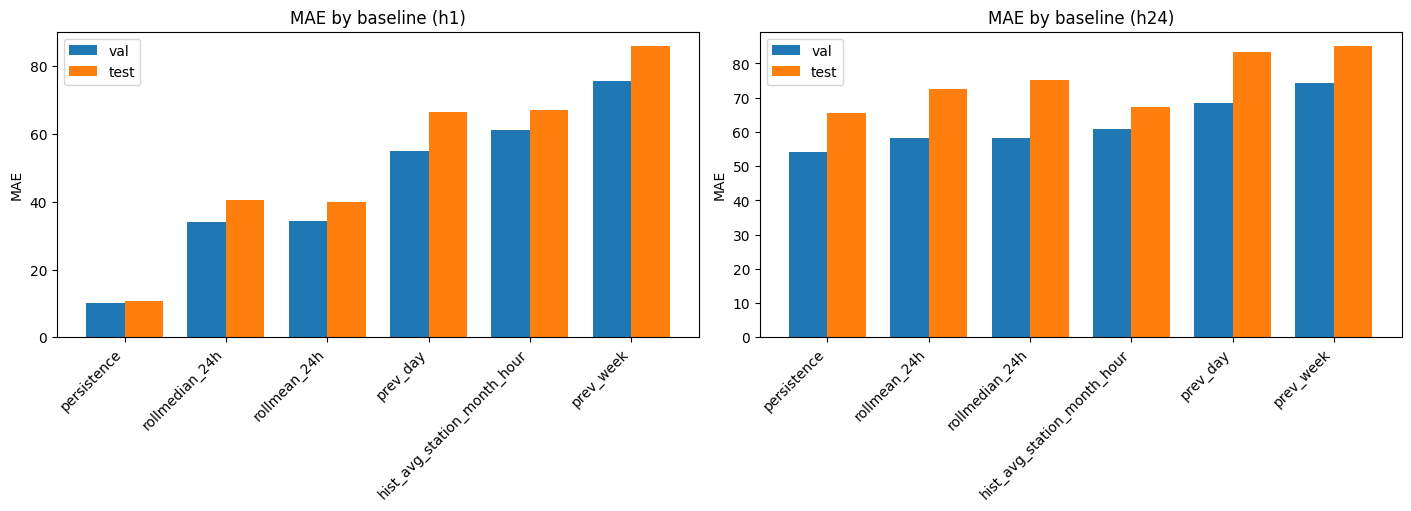

'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\reports\\figures\\temporal_baselines\\baseline_mae_by_horizon_split.png'

In [26]:
# Figure: baseline MAE by horizon and split
plot_df = overall_scores.loc[overall_scores['split'].isin(['val', 'test'])].copy()
plot_df = plot_df.sort_values(['horizon_hours', 'split', 'mae'])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), constrained_layout=True)
for ax, h in zip(axes, [1, 24]):
    sub = plot_df.loc[plot_df['horizon_hours'] == h].copy()
    # Consistent baseline ordering by validation MAE (fallback: overall MAE)
    order = (
        sub.loc[sub['split'] == 'val']
        .sort_values('mae')['baseline']
        .tolist()
    )
    if not order:
        order = sub.sort_values('mae')['baseline'].unique().tolist()

    x = np.arange(len(order))
    width = 0.38
    mae_val = sub.loc[sub['split'] == 'val'].set_index('baseline')['mae'].reindex(order)
    mae_test = sub.loc[sub['split'] == 'test'].set_index('baseline')['mae'].reindex(order)

    ax.bar(x - width/2, mae_val.to_numpy(), width=width, label='val')
    ax.bar(x + width/2, mae_test.to_numpy(), width=width, label='test')
    ax.set_title(f'MAE by baseline (h{h})')
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_ylabel('MAE')
    ax.legend(loc='best')

plt.show()
fig.savefig(FIG_BASELINE_MAE, dpi=150)
plt.close(fig)
str(FIG_BASELINE_MAE)


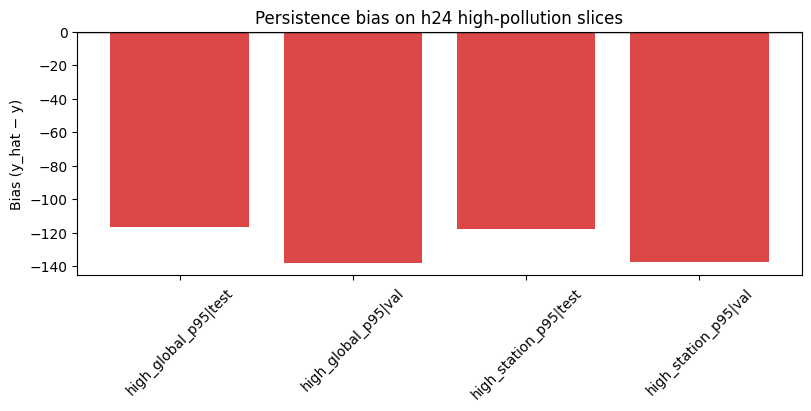

'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\reports\\figures\\temporal_baselines\\baseline_h24_high_pollution_bias.png'

In [27]:
# Figure: h24 high-pollution persistence bias (val/test; both slice flags)
bias_df = high_scores.loc[(high_scores['horizon_hours'] == 24) & (high_scores['baseline'] == 'persistence')].copy()
bias_df = bias_df.loc[bias_df['split'].isin(['val', 'test'])].copy()
bias_df = bias_df.sort_values(['slice', 'split'])

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
x_labels = [f"{r['slice']}|{r['split']}" for _, r in bias_df.iterrows()]
ax.bar(x_labels, bias_df['bias'].to_numpy(), color='tab:red', alpha=0.85)
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Persistence bias on h24 high-pollution slices')
ax.set_ylabel('Bias (y_hat − y)')
ax.tick_params(axis='x', rotation=45)

plt.show()
fig.savefig(FIG_H24_HIGH_BIAS, dpi=150)
plt.close(fig)
str(FIG_H24_HIGH_BIAS)


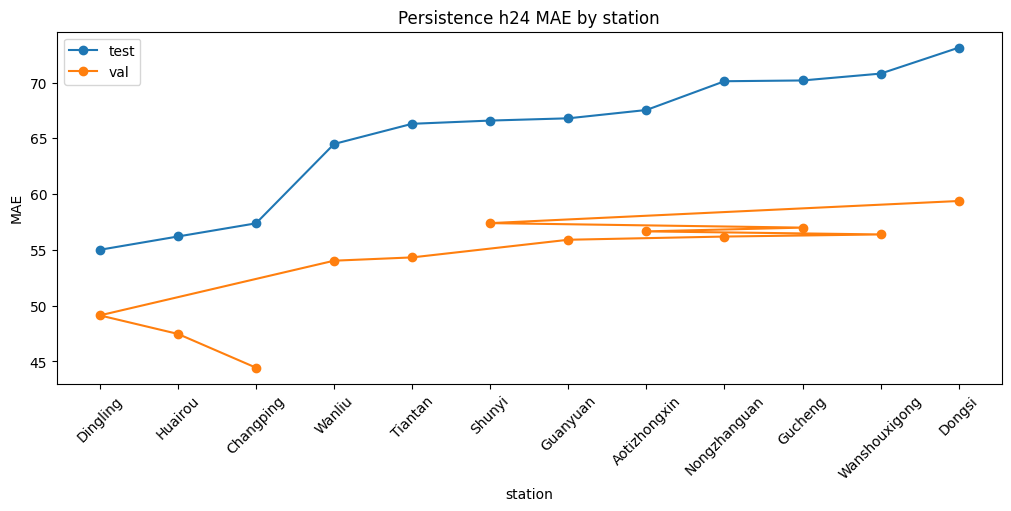

{'baseline_to_beat_parquet': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\data\\interim\\beijing_air_quality\\temporal_baselines\\baseline_to_beat.parquet',
 'station_spread_parquet': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\data\\interim\\beijing_air_quality\\temporal_baselines\\station_baseline_spread.parquet',
 'fig_baseline_mae': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\reports\\figures\\temporal_baselines\\baseline_mae_by_horizon_split.png',
 'fig_h24_high_bias': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-quality-forecasting-environmental-signals\\reports\\figures\\temporal_baselines\\baseline_h24_high_pollution_bias.png',
 'fig_persist_h24_station_spread': 'F:\\DOCUMENTOS\\CIENCIA DE DATOS\\PROYECTOS\\portfolio_data_science\\air-

In [28]:
# Figure: persistence h24 station MAE spread (val/test)
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for split, g in station_spread.groupby('split', sort=True):
    ax.plot(g['station'].astype(str).to_list(), g['mae'].to_numpy(), marker='o', label=split)
ax.set_title('Persistence h24 MAE by station')
ax.set_xlabel('station')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='best')

plt.show()
fig.savefig(FIG_PERSIST_H24_STATION_SPREAD, dpi=150)
plt.close(fig)
{
    'baseline_to_beat_parquet': str(OUT_BASELINE_TO_BEAT),
    'station_spread_parquet': str(OUT_STATION_SPREAD),
    'fig_baseline_mae': str(FIG_BASELINE_MAE),
    'fig_h24_high_bias': str(FIG_H24_HIGH_BIAS),
    'fig_persist_h24_station_spread': str(FIG_PERSIST_H24_STATION_SPREAD),
}


## 11. Persist baseline artifacts


In [29]:
# Persist predictions
pred_h1.to_parquet(OUT_PRED_H1, index=False)
pred_h24.to_parquet(OUT_PRED_H24, index=False)

# Persist scores
overall_scores.to_parquet(OUT_SCORE_OVERALL, index=False)
by_station_scores.to_parquet(OUT_SCORE_BY_STATION, index=False)
high_scores.to_parquet(OUT_SCORE_HIGH, index=False)

run_summary = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'contract_dir': str(CONTRACT_DIR),
    'assembled_path': str(ASSEMBLED_PATH),
    'min_obs_roll24': int(MIN_OBS_ROLL24),
    'baselines': [
        'persistence',
        'previous_day',
        'previous_week',
        'rolling_mean_24h',
        'rolling_median_24h',
        'hist_avg_station_month_hour',
    ],
    'artifacts': {
        'baseline_predictions_h1': str(OUT_PRED_H1),
        'baseline_predictions_h24': str(OUT_PRED_H24),
        'baseline_scores_overall': str(OUT_SCORE_OVERALL),
        'baseline_scores_by_station': str(OUT_SCORE_BY_STATION),
        'baseline_scores_high_pollution': str(OUT_SCORE_HIGH),
        'baseline_to_beat': str(OUT_BASELINE_TO_BEAT),
        'station_baseline_spread': str(OUT_STATION_SPREAD),
        'fig_baseline_mae_by_horizon_split': str(FIG_BASELINE_MAE),
        'fig_h24_high_pollution_bias': str(FIG_H24_HIGH_BIAS),
        'fig_persistence_h24_station_mae_spread': str(FIG_PERSIST_H24_STATION_SPREAD),
    },
}

OUT_RUN_SUMMARY.write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

# Artifact status preview
artifact_rows = []
for p in [OUT_PRED_H1, OUT_PRED_H24, OUT_SCORE_OVERALL, OUT_SCORE_BY_STATION, OUT_SCORE_HIGH, OUT_BASELINE_TO_BEAT, OUT_STATION_SPREAD, FIG_BASELINE_MAE, FIG_H24_HIGH_BIAS, FIG_PERSIST_H24_STATION_SPREAD, OUT_RUN_SUMMARY]:
    artifact_rows.append({
        'artifact': p.name,
        'exists': bool(p.exists()),
        'bytes': int(p.stat().st_size) if p.exists() else None,
        'path': str(p),
    })
pd.DataFrame(artifact_rows)


,artifact,exists,bytes,path
0,baseline_predictions_h1.parquet,True,5700290,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
1,baseline_predictions_h24.parquet,True,5678863,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
2,baseline_scores_overall.parquet,True,7142,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
3,baseline_scores_by_station.parquet,True,19560,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
4,baseline_scores_high_pollution.parquet,True,8297,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
5,baseline_to_beat.parquet,True,7066,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
6,station_baseline_spread.parquet,True,6042,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
7,baseline_mae_by_horizon_split.png,True,58981,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
8,baseline_h24_high_pollution_bias.png,True,47718,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
9,persistence_h24_station_mae_spread.png,True,77326,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...


## 12. Notebook close

Notebook 04 ends after persisting baseline predictions/scores plus compact baseline summaries and figures for downstream comparison.
Downstream ML notebooks should reuse the same forecasting contract and compare candidates against these baselines.
